In [1]:
%%latex
\title{Sample Document}

<IPython.core.display.Latex object>

# Recreating Figure 4 from the Wilder et al. (2018) paper
---
---
To do this we use the package **PySPEDAS**. PySPEDAS is a Python interface for the IDL-based Space Physics Environment Data Analysis Software (**SPEDAS**). This package is designed to streamline access to satellite mission data (e.g., MMS, THEMIS, WIND) and perform time-series analysis, coordinate transformations, and field-aligned projections. It integrates with **PyTplot**, the Python version of the IDL-based tplot library for visualization and analysis. 

In the upcoming **Pyspedas 2.0** version PyTplot will no longer be a separate package but its functionality has been fully absorbed into the PySPEDAS namespace. This consolidation simplifies environment setup and ensures that all tplot variable operations and plotting routines are accessible directly through PySPEDAS, eliminating ambiguity around legacy packages like *pytplot-mpl-temp*.


In [2]:
import pyspedas
from pyspedas import tplot
import numpy as np

Define the time range for the December 9, 2015 event shown in Figure 4

In [3]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']

## Load the electron and ion data from the Fast Plasma Investigation (FPI) instrument

---
---

- The `pyspedas.mms.fpi` function first connects to the MMS data server and downloads the relevant `CDF` (Common Data Format) files based on the specified time range, data rate, data level, and datatype. These files contain structured, mission-specific measurements from the FPI instrument.

- Once downloaded, PySPEDAS parses the CDF contents and extracts selected variables using the varformat filter. These variables are then processed and stored as tplot variables in memory, enabling time-series visualization and analysis. Variable names like `mms1_des_energyspectr_omni_brst` are generated during this step, corresponding to omnidirectional energy spectra. Additional physical quantities such as number density, bulk velocity, and temperature anisotropy can also be read in, depending on the specified datatype and varformat.

---

In [4]:
fpi_vars = pyspedas.mms.fpi(trange=trange, 
                            datatype=['des-dist', 'dis-dist', 'des-moms', 'dis-moms'], 
                            level='l2', 
                            data_rate='brst',
                            varformat=['mms1_des_energyspectr_omni_brst',
                                       'mms1_dis_energyspectr_omni_brst',
                                       'mms1_des_numberdensity_brst',
                                       'mms1_dis_numberdensity_brst', 
                                       'mms1_dis_bulkv_gse_brst',
                                       'mms1_des_bulkv_gse_brst', '*temppara*', '*tempperp*'],
                            time_clip=True)

03-Nov-25 15:13:57: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-dist, after sorting and filtering:
03-Nov-25 15:13:57: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-dist/2015/12/09/mms1_fpi_brst_l2_des-dist_20151209050044_v3.3.0.cdf
03-Nov-25 15:13:57: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-dist, after sorting and filtering:
03-Nov-25 15:13:57: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-dist/2015/12/09/mms1_fpi_brst_l2_dis-dist_20151209050044_v3.3.0.cdf
03-Nov-25 15:13:57: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
03-Nov-25 15:13:57: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
03-Nov-25 15:13:57: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
03-Nov-25 15:13:57: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/

The `datatype` parameter specifies the type of data to be loaded from the Fast Plasma Investigation (FPI) instrument.

---

- `des-dist`: Dual Electron Spectrometer (DES) distributions. This loads the 3D electron energy and angle distributions, which are then used to create the electron energy spectra.

- `dis-dist`: Dual Ion Spectrometer (DIS) distributions. This loads the 3D ion energy and angle distributions, used to create the ion energy spectra.

- `des-moms`: Dual Electron Spectrometer moments. This loads the moments of the electron distributions, including the electron number density, bulk velocity, and pressure tensor.

- `dis-moms`: Dual Ion Spectrometer moments. This loads the moments of the ion distributions, including the ion number density, bulk velocity, and pressure tensor.

***Note***: 'Dual' because it has two identical sensor heads, enabling near 4&pi; steradian coverage.This design captures full-sky particle distributions without spinning the spacecraft and is essential for resolving fast-changing plasma structures during reconnection events.

---

`level='l2'`: level parameter referring to the data processing level. In this case, 'l2' stands for Level 2 data. This is a standard term in space physics for data that has been calibrated and processed into physical units, ready for scientific analysis.

---

`data_rate='brst'`: burst mode that provides 30 ms resolution, essential for resolving electron-scale structures like jets and dissipation regions. The other option is `fast` or fast mode which offers ~150 ms resolution, suitable for large-scale events but insufficient for fine-scale dynamics. Wilder et al. (2018) focuses on small, fast-moving features in the electron diffusion region, requiring high-cadence data only available in `brst`.

---
`varformat`: The file variable formats to load into tplot. Wildcard character “*” is accepted. Default: None (all variables are loaded)

`time_clip (bool)`: data will be clipped to the exact trange specified by the `trange` keyword. Default: False

---

## Load magnetic field data from the Flux Gate Magnetometer (FGM) instrument

In [5]:
fgm_vars = pyspedas.mms.fgm(trange=trange, probe=1, data_rate='brst',
                            varformat='mms1_fgm_b_gse_brst_l2',time_clip=True)

03-Nov-25 15:13:58: Loading files for group: probe: 1, drate: brst, level: l2, datatype: , after sorting and filtering:
03-Nov-25 15:13:58: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf


## Load electric field data from the Electric-field Double Probe (EDP) instrument

In [6]:
edp_vars = pyspedas.mms.edp(trange=trange,
                            probe=1,
                            data_rate='brst',
                            varformat=['mms1_edp_dce_gse_brst_l2', 'mms1_edp_dce_par_epar_brst_l2'],
                            time_clip=True)

03-Nov-25 15:13:59: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dce, after sorting and filtering:
03-Nov-25 15:13:59: /Users/rejohn/Data_Speedas/mms/mms1/edp/brst/l2/dce/2015/12/09/mms1_edp_brst_l2_dce_20151209050044_v2.2.0.cdf


To print out the list of all current Tplot Variables stored in memory, use `pyspedas.tplot_names(quiet=False)`. The option `quiet=False` (default) prints the variable names to the console. Setting `quiet=True` suppresses the output and returns the variable names as a list.

In [7]:
pyspedas.tplot_names()

0 : mms1_des_energyspectr_omni_brst
1 : mms1_des_numberdensity_brst
2 : mms1_des_bulkv_gse_brst
3 : mms1_des_temppara_brst
4 : mms1_des_tempperp_brst
5 : mms1_dis_energyspectr_omni_brst
6 : mms1_dis_numberdensity_brst
7 : mms1_dis_bulkv_gse_brst
8 : mms1_dis_temppara_brst
9 : mms1_dis_tempperp_brst
10 : mms1_des_errorflags_brst_moms
11 : mms1_des_compressionloss_brst_moms
12 : mms1_des_errorflags_brst_dist
13 : mms1_des_compressionloss_brst_dist
14 : mms1_dis_errorflags_brst_moms
15 : mms1_dis_compressionloss_brst_moms
16 : mms1_dis_errorflags_brst_dist
17 : mms1_dis_compressionloss_brst_dist
18 : mms1_des_errorflags_brst_dist_flagbars_dist
19 : mms1_des_compressionloss_brst_moms_flagbars
20 : mms1_dis_compressionloss_brst_moms_flagbars
21 : mms1_des_compressionloss_brst_dist_flagbars
22 : mms1_dis_compressionloss_brst_dist_flagbars
23 : mms1_dis_errorflags_brst_dist_flagbars_dist
24 : mms1_des_errorflags_brst_moms_flagbars_full
25 : mms1_des_errorflags_brst_moms_flagbars_main
26 : mms

['mms1_des_energyspectr_omni_brst',
 'mms1_des_numberdensity_brst',
 'mms1_des_bulkv_gse_brst',
 'mms1_des_temppara_brst',
 'mms1_des_tempperp_brst',
 'mms1_dis_energyspectr_omni_brst',
 'mms1_dis_numberdensity_brst',
 'mms1_dis_bulkv_gse_brst',
 'mms1_dis_temppara_brst',
 'mms1_dis_tempperp_brst',
 'mms1_des_errorflags_brst_moms',
 'mms1_des_compressionloss_brst_moms',
 'mms1_des_errorflags_brst_dist',
 'mms1_des_compressionloss_brst_dist',
 'mms1_dis_errorflags_brst_moms',
 'mms1_dis_compressionloss_brst_moms',
 'mms1_dis_errorflags_brst_dist',
 'mms1_dis_compressionloss_brst_dist',
 'mms1_des_errorflags_brst_dist_flagbars_dist',
 'mms1_des_compressionloss_brst_moms_flagbars',
 'mms1_dis_compressionloss_brst_moms_flagbars',
 'mms1_des_compressionloss_brst_dist_flagbars',
 'mms1_dis_compressionloss_brst_dist_flagbars',
 'mms1_dis_errorflags_brst_dist_flagbars_dist',
 'mms1_des_errorflags_brst_moms_flagbars_full',
 'mms1_des_errorflags_brst_moms_flagbars_main',
 'mms1_des_errorflags_br

### Renaming MMS variables by physical quantity and coordinate frame

In [8]:
from pyspedas import tplot_rename

In [9]:
# Omnidirectional energy spectra
tplot_rename('mms1_des_energyspectr_omni_brst', 'ene_omni_e')   # Electron energy spectra (omni-directional)
tplot_rename('mms1_dis_energyspectr_omni_brst', 'ene_omni_i')   # Ion energy spectra (omni-directional)

In [10]:
# Density
tplot_rename('mms1_des_numberdensity_brst', 'n_e')  # Electron number density
tplot_rename('mms1_dis_numberdensity_brst', 'n_i')  # Ion number density

In [11]:
# Temperature
tplot_rename('mms1_des_temppara_brst', 't_para_e')  # Electron parallel temperature
tplot_rename('mms1_des_tempperp_brst', 't_perp_e')  # Electron perpendicular temperature
tplot_rename('mms1_dis_temppara_brst', 't_para_i')  # Ion parallel temperature
tplot_rename('mms1_dis_tempperp_brst', 't_perp_i')  # Ion perpendicular temperature

In [12]:
# Bulk velocity in GSE
tplot_rename('mms1_des_bulkv_gse_brst', 'bulkv_e_gse')  # Electron bulk velocity (GSE)
tplot_rename('mms1_dis_bulkv_gse_brst', 'bulkv_i_gse')  # Ion bulk velocity (GSE)

In [13]:
# Magnetic field in GSE
tplot_rename('mms1_fgm_b_gse_brst_l2_bvec', 'bvec_gse')    # Magnetic field (GSE)
tplot_rename('mms1_fgm_b_gse_brst_l2_btot', 'bmag')      # Magnetic field magnitude

In [14]:
# Electric field in GSE
tplot_rename('mms1_edp_dce_gse_brst_l2', 'evec_gse')  # Electric field (GSE)
tplot_rename('mms1_edp_dce_par_epar_brst_l2', 'epar_gse')  # Electric field parallel component (GSE)

### To ensure all FPI and EDP variables are mathematically compatible for calculations (like J and J⋅E′), we re-sample (interpolate) all data onto the highest stable reference: the bvec_gse time base, using linear interpolation and the `_s` suffix.

In [15]:
interp_to_vars = [
    # FPI Spectra
    'ene_omni_e', 'ene_omni_i', 
    # FPI Densities
    'n_e', 'n_i', 
    # FPI Temperatures
    't_para_e', 't_perp_e', 't_para_i', 't_perp_i', 
    # FPI Velocities
    'bulkv_e_gse', 'bulkv_i_gse', 
    # EDP Electric Fields
    'evec_gse', 'epar_gse'
]

In [16]:
# Create a list of new names with the '_s' suffix
new_res_names = [name + '_s' for name in interp_to_vars]

In [17]:
pyspedas.tinterpol(names=interp_to_vars,
                   interp_to='bvec_gse',
                   newname=new_res_names,
                   method='linear')

03-Nov-25 15:14:02: tinterpol (linear) was applied to: ene_omni_e_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: ene_omni_i_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: n_e_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: n_i_s


03-Nov-25 15:14:02: tinterpol (linear) was applied to: t_para_e_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: t_perp_e_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: t_para_i_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: t_perp_i_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: bulkv_e_gse_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: bulkv_i_gse_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: evec_gse_s
03-Nov-25 15:14:02: tinterpol (linear) was applied to: epar_gse_s


## LMN transformation using LMN matrix from Wilder et al., 2018
Creating a LMN transformation matrix using the hard-coded LMN coordinates from the paper:


In [18]:
L = [-0.104, -0.59, 0.80]
M = [0.38, -0.77, -0.514]
N = [0.920, 0.250, 0.302]
# Combine the L, M, and N vectors into a single 3x3 matrix
lmn_matrix_data = np.array([L, M, N])

Use magnetic field timestamps as the reference timebase for the LMN transformation. This ensures consistent alignment when rotating other burst-mode variables (e.g., Vi, Ve, E) into LMN.

In [19]:
times = pyspedas.get_data('bvec_gse').times

Since the LMN basis vectors (**L,M,N**) were calculated only once (e.g., from Mean Variance Analysis on the full interval) and are assumed constant for all time steps, we must tile the single 3×3 rotation matrix across every time stamp in the `times` array. This creates the time-dependent `lmn_matrix` variable required for vector rotation functions like `pyspedas.tvector_rotate`.

In [20]:
# The (len, 1, 1) pattern repeats the matrix across the time axis (dimension 0).
tiled_lmn_matrix = np.tile(lmn_matrix_data, (len(times), 1, 1))

In [21]:
pyspedas.store_data('lmn_matrix', data={'x': times, 'y': tiled_lmn_matrix})

True

In [22]:
# Adding metadata that the matrix transforms vectors FROM GSE TO LMN.
pyspedas.rotmat_set_coords(varname='lmn_matrix', in_coords='GSE', out_coords='LMN')

03-Nov-25 15:14:04: store_data: Neither data array nor newname supplied, nothing to do.


In [23]:
# Verify the coordinate system metadata
pyspedas.rotmat_get_coords('lmn_matrix')

('GSE', 'LMN')

### Rotating bulk velocity to LMN coordinates

In [24]:
pyspedas.tvector_rotate(mat_var_in='lmn_matrix',vec_var_in='bulkv_e_gse_s',
                        newname='bulkv_e_lmn_s')
pyspedas.tvector_rotate(mat_var_in='lmn_matrix',vec_var_in='bulkv_i_gse_s',
                        newname='bulkv_i_lmn_s')

03-Nov-25 15:14:05: Setting coordinate system for bulkv_e_lmn_s
03-Nov-25 15:14:05: Setting coordinate system for bulkv_i_lmn_s


['bulkv_i_lmn_s']

### Rotating magnetic field vector to LMN coordinates

In [25]:
pyspedas.tvector_rotate(mat_var_in='lmn_matrix',vec_var_in='bvec_gse',
                        newname='bvec_lmn')

03-Nov-25 15:14:06: Setting coordinate system for bvec_lmn


['bvec_lmn']

### Rotating electric field vector to LMN coordinates

In [26]:
pyspedas.tvector_rotate(mat_var_in='lmn_matrix',vec_var_in='evec_gse_s',
                        newname='evec_lmn_s')

03-Nov-25 15:14:06: Setting coordinate system for evec_lmn_s


['evec_lmn_s']

### Calculating current density $(J = n*e*(V_i - V_e))$ in S.I. units in LMN coordinates

In [27]:
from scipy.constants import elementary_charge  # e = 1.602176634e-19 C in SI units
ele_charge = elementary_charge

Extracting units of the tplot variables

In [28]:
pyspedas.get_units('bulkv_i_lmn_s'), pyspedas.get_units('n_e')

('km/s', 'cm^-3')

Converting electron and ion velocities to $ms^{-1}$:

In [29]:
_, bulkv_i_lmn_s = pyspedas.get_data('bulkv_i_lmn_s')
_, bulkv_e_lmn_s = pyspedas.get_data('bulkv_e_lmn_s')

In [30]:
bulkv_i_lmn_s = bulkv_i_lmn_s * 1e3  # Convert from km/s to m/s
bulkv_e_lmn_s = bulkv_e_lmn_s * 1e3  # Convert from km/s to m/s

Converting electron number density to $m^{-3}$:

In [31]:
_, n_e_s = pyspedas.get_data('n_e_s')  # in cm^-3
n_e_s = n_e_s * 1e6  # Convert from cm^-3 to m^-3

Calculating and saving $J$ as a tplot variable:

In [32]:
# Calculate current density vector in LMN coordinates (in µA/m²)
jvec_lmn = n_e_s.reshape(-1, 1) * ele_charge * (bulkv_i_lmn_s - bulkv_e_lmn_s)*1e6 
pyspedas.store_data('jvec_lmn', data={'x': times, 'y': jvec_lmn})

True

### Verifying LMN Transformation Against Fig 4 from Wilder et al. (2018)

We will compare the bulk flow velocities in LMN coordinates computed using our code with those shown in Fig. 4 of Wilder et al. (2018).

In [33]:
pyspedas.timespan(trange)  # global time span for the pyspedas session

In [34]:
# Panel 5 - Ion bulk velocity in LMN
pyspedas.options('bulkv_i_lmn_s', 'legend_names', ['$L$', '$M$', '$N$'])
# Set colors and y-axis
pyspedas.options('bulkv_i_lmn_s', 'ytitle', '$V_{IMVA}$')
pyspedas.options('bulkv_i_lmn_s', 'line_width', 1.5)

# Panel 6 - Electron bulk velocity in LMN
pyspedas.options('bulkv_e_lmn_s', 'legend_names', ['$L$', '$M$', '$N$'])
pyspedas.options('bulkv_e_lmn_s', 'ytitle', '$V_{EMVA}$')
pyspedas.options('bulkv_e_lmn_s', 'line_width', 1.5)

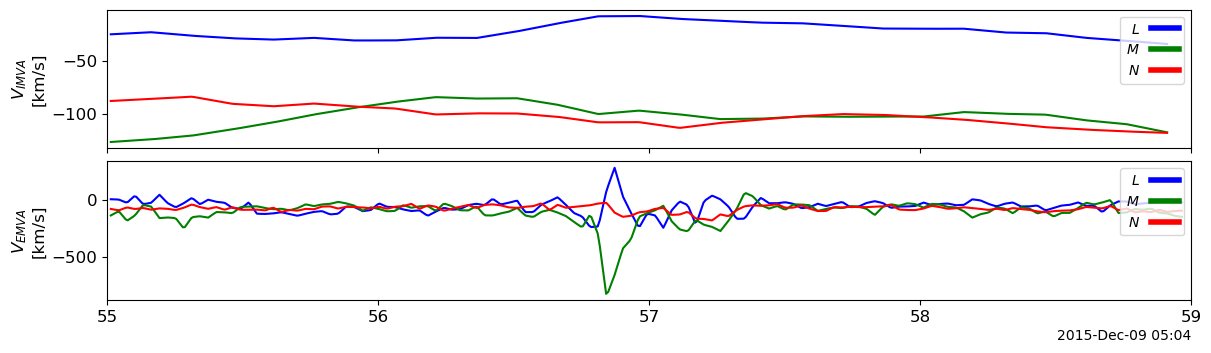

In [35]:
pyspedas.tplot(['bulkv_i_lmn_s',
                'bulkv_e_lmn_s',
                ], xsize=12, ysize=3.5)

<img src="Fig4_wilder2018_lmn_comparison.png" alt="LMN Diagnostic Plot" width="92%"/>

The computed LMN bulk velocity profiles match Fig. 4 from Wilder et al. (2018), confirming the fidelity of the LMN transformation.

## Testing FAC matrix implementation

To validate the inbuilt fac subroutine in PySPEDAS, we perform the following checks:

1. Plot the raw field-aligned electric field ($E_{\parallel}$) from MMS data.
2. Use the fac subroutine to compute $E_{\parallel}$ and plot the result.
3. Independently estimate the magnetic field direction, project the electric field onto it, and normalize by |B| to obtain $E_{\parallel}$.

If all three methods yield consistent $E_{\parallel}$ profiles, the transformation is verified.

### 1. Raw field-aligned electric field ($E_{\parallel}$) from MMS data:

In [36]:
_, epar_gse_s = pyspedas.get_data('epar_gse_s')
epar_gse_s_noerr = epar_gse_s[:, 1]  # Exclude error component
pyspedas.store_data('epar_gse_s_noerr', data={'x': times, 'y': epar_gse_s_noerr})

True

### 2. Estimating $E_{\parallel}$ using the inbuilt FAC functions:

In [37]:
# Using inbuilt FAC functions:
pyspedas.fac_matrix_make(mag_var_name='bvec_gse', other_dim='Xgse', newname='fac_matrix')

03-Nov-25 15:14:17: store_data: Neither data array nor newname supplied, nothing to do.


'fac_matrix'

In [38]:
# Rotate the interpolated E vector using the created matrix
print("Rotating evec_gse_s to FAC coordinates...")
pyspedas.tvector_rotate(mat_var_in='fac_matrix', vec_var_in='evec_gse_s', 
                        newname='evec_gse_s_fac')

03-Nov-25 15:14:17: Setting coordinate system for evec_gse_s_fac


Rotating evec_gse_s to FAC coordinates...


['evec_gse_s_fac']

In [39]:
_, evec_gse_s_fac = pyspedas.get_data('evec_gse_s_fac')

In [40]:
epar_gse_s_fac = evec_gse_s_fac[:, 2]  # Z component (parallel to B in FAC)

In [41]:
pyspedas.store_data('epar_gse_s_fac', data={'x': times, 'y': epar_gse_s_fac})

True

### 3. Computing $E_{\parallel}$ using projection:
We normalize the B-field (bvec_gse) to get the unit vector (bhat_gse).

In [42]:
pyspedas.tnormalize('bvec_gse', newname='bhat_gse')

'bhat_gse'

Then dot product the E-field (evec_gse_s) with the B-field unit vector (bhat_gse):

In [43]:
pyspedas.tdotp('evec_gse_s', 'bhat_gse', newname='epar_gse_s_dotp')

'epar_gse_s_dotp'

### Comparing the plots:

In [44]:
pyspedas.options('epar_gse_s_noerr', 'legend_names', 'Raw $E_{\\parallel}$')
pyspedas.options('epar_gse_s_noerr', 'ytitle', '$E_{\\parallel}$')

pyspedas.options('epar_gse_s_fac', 'legend_names', 'FAC $E_{\\parallel}$')
pyspedas.options('epar_gse_s_fac', 'ytitle', '$E_{\\parallel}$')

pyspedas.options('epar_gse_s_dotp', 'legend_names', 'Projection $E_{\\parallel}$')
pyspedas.options('epar_gse_s_dotp', 'ytitle', '$E_{\\parallel}$')

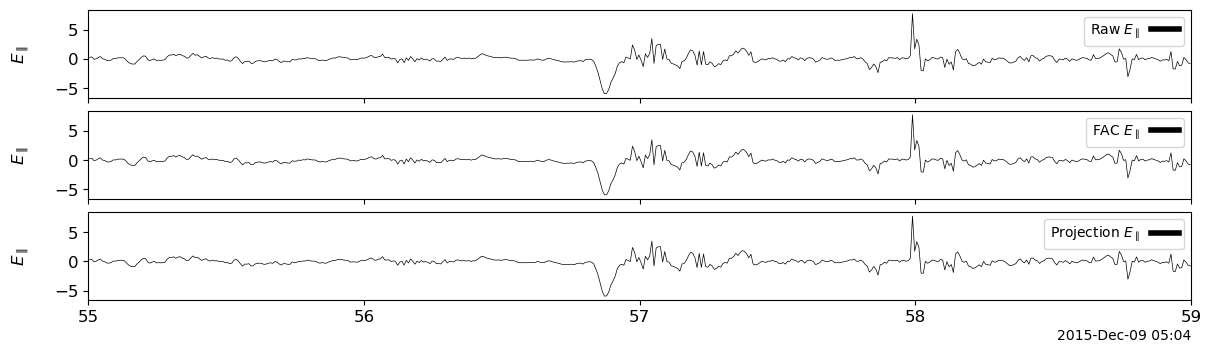

In [45]:
pyspedas.tplot(['epar_gse_s_noerr', 'epar_gse_s_fac', 'epar_gse_s_dotp'], xsize=12, ysize=3.5)

All three methods yield identical parallel electric field profiles, confirming that the inbuilt FAC rotation in PySPEDAS accurately reproduces $E_{\parallel}$.

## Computation of $\mathbf{J} \cdot \mathbf{E}'$ in Field-Aligned Coordinates (FAC)

In [1]:
pyspedas.get_units('n_e_s'), pyspedas.get_units('bulkv_e_gse_s'), pyspedas.get_units('bulkv_i_gse_s')

NameError: name 'pyspedas' is not defined

In [2]:
pyspedas.get_units('evec_gse_s'), pyspedas.get_units('bvec_gse')

NameError: name 'pyspedas' is not defined

Converting the bulk flow from km/s to m/s:

In [3]:
_, bulkv_i_gse_s = pyspedas.get_data('bulkv_i_gse_s')
_, bulkv_e_gse_s = pyspedas.get_data('bulkv_e_gse_s')

NameError: name 'pyspedas' is not defined

In [4]:
bulkv_i_gse_s = bulkv_i_gse_s * 1e3  # Convert from km/s to m/s
bulkv_e_gse_s = bulkv_e_gse_s * 1e3  # Convert from km/s to m/s

NameError: name 'bulkv_i_gse_s' is not defined

Converting electron number density to $m^{-3}$:

In [5]:
_, n_e_s = pyspedas.get_data('n_e_s')  # in cm^-3
n_e_s = n_e_s * 1e6  # Convert from cm^-3 to m^-3

NameError: name 'pyspedas' is not defined

Calculate J = n * e * (V_i - V_e) in GSE and in SI units:

In [6]:
jvec_gse = n_e_s.reshape(-1, 1) * ele_charge * (bulkv_i_gse_s - bulkv_e_gse_s)
pyspedas.store_data('jvec_gse', data={'x': times, 'y': jvec_gse})
pyspedas.set_coords('jvec_gse', 'GSE')

NameError: name 'n_e_s' is not defined

Converting the electron bulk flow from $km/s$ to $m/s$:

In [7]:
_, bulkv_e_gse_s = pyspedas.get_data('bulkv_e_gse_s')
bulkv_e_gse_s = bulkv_e_gse_s * 1e3  # in m/s
pyspedas.store_data('bulkv_e_gse_s', data={'x': times, 'y': bulkv_e_gse_s})
pyspedas.set_coords('bulkv_e_gse_s', 'GSE')

NameError: name 'pyspedas' is not defined

Converting the magnetic field from nT to T:

In [8]:
_, bvec_gse = pyspedas.get_data('bvec_gse')
bvec_gse = bvec_gse * 1e-9  # in T
pyspedas.store('bvec_gse', data={'x': times, 'y': bvec_gse})
pyspedas.set_coords('bvec_gse', 'GSE')

NameError: name 'pyspedas' is not defined

Converting the electric field from $mV/m$ to $V/m$:

In [54]:
_, evec_gse_s = pyspedas.get_data('evec_gse_s')
evec_gse_s = evec_gse_s * 1e-3 # in V/m
pyspedas.store('evec_gse_s', data={'x': times, 'y': evec_gse_s})
pyspedas.set_coords('evec_gse_s', 'GSE')

09-Oct-25 13:52:58: Setting coordinate system for evec_gse_s


True

Computing **$v_e \times B$**:

In [55]:
pyspedas.tcrossp('bulkv_e_gse_s', 'bvec_gse', newname='vxb_gse')

'vxb_gse'

Estimating **$E^{\prime} = E + v_e \times B$**:

In [56]:
pyspedas.add('evec_gse_s', 'vxb_gse', newname='evec_gse_s_p')
pyspedas.set_coords('evec_gse_s_p', 'GSE')

09-Oct-25 13:53:00: Setting coordinate system for evec_gse_s_p


True

Applying FAC rotation:

In [57]:
# Using inbuilt FAC functions:
pyspedas.fac_matrix_make(mag_var_name='bvec_gse', other_dim='Xgse', newname='fac_matrix')

09-Oct-25 13:53:01: store_data: Neither data array nor newname supplied, nothing to do.


'fac_matrix'

In [58]:
pyspedas.tvector_rotate(mat_var_in='fac_matrix', vec_var_in='jvec_gse', 
                        newname='jvec_fac')
pyspedas.tvector_rotate(mat_var_in='fac_matrix', vec_var_in='evec_gse_s_p', 
                        newname='evec_fac')

09-Oct-25 13:53:01: Setting coordinate system for jvec_fac
09-Oct-25 13:53:01: Setting coordinate system for evec_fac


['evec_fac']

Computing $\mathbf{J} \cdot \mathbf{E}'$ component-wise:

In [59]:
# Splitting tplot variables into components
pyspedas.split_vec('jvec_fac')

['jvec_fac_x', 'jvec_fac_y', 'jvec_fac_z']

In [60]:
pyspedas.split_vec('evec_fac')

['evec_fac_x', 'evec_fac_y', 'evec_fac_z']

In [61]:
pyspedas.multiply('jvec_fac_z', 'evec_fac_z', newname='j_ep_par')

'j_ep_par'

In [68]:
pyspedas.add('j_ep_x', 'j_ep_y', newname='j_ep_perp')

'j_ep_perp'

Converting $J.E'$ from $W/m^3$ to $nW/m^3$:

In [69]:
_, j_ep_par = pyspedas.get_data('j_ep_par')
_, j_ep_perp = pyspedas.get_data('j_ep_perp')
j_ep_par = j_ep_par * 1e9   # in nW/m^3
j_ep_perp = j_ep_perp * 1e9  # in nW/m^3
pyspedas.store_data('j_ep_par', data={'x': times, 'y': j_ep_par})
pyspedas.store_data('j_ep_perp', data={'x': times, 'y': j_ep_perp})

True

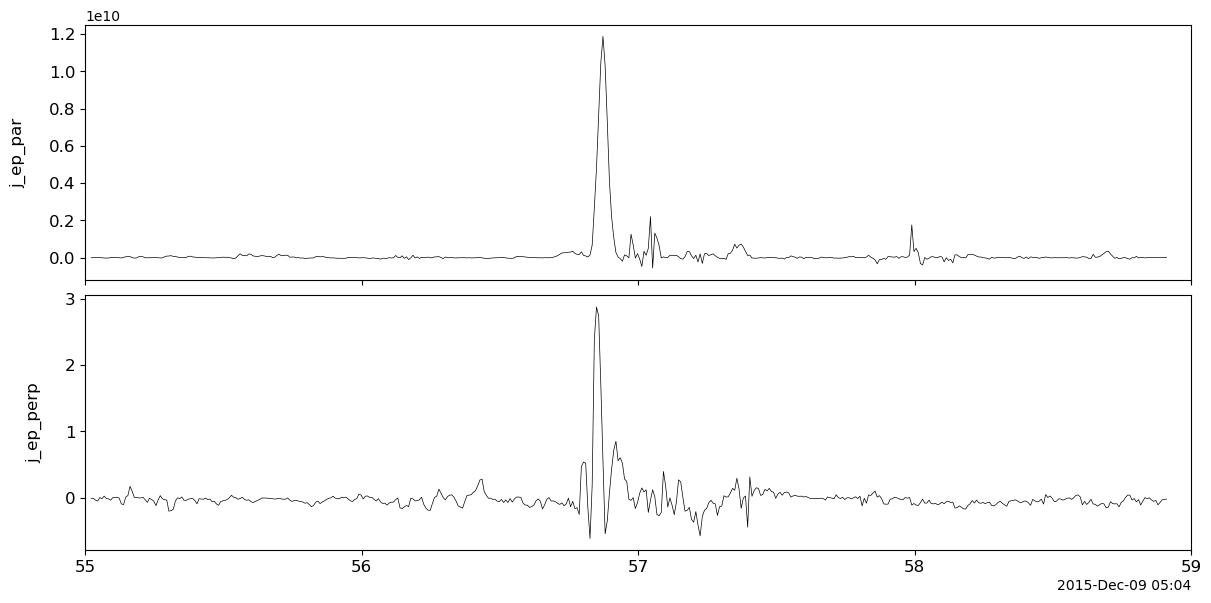

In [70]:
pyspedas.tplot(['j_ep_par','j_ep_perp'])

## Making the Plot

In [113]:
# Panel 1,2 - omnidirectional energy spectra
# Set y-axis labels
pyspedas.options('ene_omni_e', 'ytitle', 'elec E')
pyspedas.options('ene_omni_i', 'ytitle', 'ion E')

In [114]:
# Panel 3 - Combine electron and ion number densities
pyspedas.store_data('combined_density', data=[
    'n_e_s',
    'n_i_s'
])

# Assign legend labels
pyspedas.options('combined_density', 'legend_names', ['Electron', 'Ion'])

# Set colors and y-axis
pyspedas.options('combined_density', 'color', ['blue', 'red'])
pyspedas.options('combined_density', 'ytitle', 'n')
pyspedas.options('combined_density', 'line_width', 1)
pyspedas.options('combined_density', 'yrange', [10, 100])

In [115]:
# Panel 4 - Combine electron and ion temperatures
pyspedas.store_data('combined_temp', data=[
    't_para_e', 't_perp_e', 't_para_i', 't_perp_i'])

# Set colors and y-axis
pyspedas.options('combined_temp', 'color', ['red', 'black', 'green', 'blue'])
pyspedas.options('combined_temp', 'ytitle', 'T')
pyspedas.options('combined_temp', 'line_width', 1.5)
pyspedas.options('combined_temp', 'yrange', [10, 500])

In [116]:
# Panel 5 - Ion bulk velocity in LMN
pyspedas.options('bulkv_i_lmn_s', 'legend_names', ['$L$', '$M$', '$N$'])
pyspedas.options('bulkv_i_lmn_s', 'line_width', 1.5)
# Set colors and y-axis
pyspedas.options('bulkv_i_lmn_s', 'ytitle', '$V_{IMVA}$')

# Panel 6 - Electron bulk velocity in LMN
pyspedas.options('bulkv_e_lmn_s', 'legend_names', ['$L$', '$M$', '$N$'])
pyspedas.options('bulkv_e_lmn_s', 'line_width', 1.5)
pyspedas.options('bulkv_e_lmn_s', 'ytitle', '$V_{EMVA}$')

In [117]:
# Panel 7 - Magnetic field in LMN
pyspedas.store_data('combined_B_lmn', data=[
    'bvec_lmn',
    'bmag'
])
pyspedas.options('combined_B_lmn', 'line_width', 1.5)
pyspedas.options('combined_B_lmn', 'legend_names', ['$B_L$', '$B_M$', '$B_N$', '|B|'])
pyspedas.options('combined_B_lmn', 'ytitle', '$B$')

In [118]:
# Panel 8 - Electric field parallel component with error
pyspedas.options('epar_gse_s', 'legend_names', ['$E_{\\parallel}$', '$E_{err}$'])
# Set colors and y-axis
pyspedas.options('epar_gse_s', 'ytitle', '$E_{\\parallel}$')
pyspedas.options('epar_gse_s', 'line_width', 1.5)

In [119]:
# Panel 9 - Current density in LMN
pyspedas.options('jvec_lmn', 'legend_names', ['$L$', '$M$', '$N$'])
pyspedas.options('jvec_lmn', 'ytitle', r'J' + '\n' + r'[$\mu A/m^2$]')
pyspedas.options('jvec_lmn', 'line_width', 1.5)

In [120]:
# Panel 10 - J·E' contributions
pyspedas.store_data('combined_j_ep', data=[
    'j_ep_par',
    'j_ep_perp'
])

pyspedas.options('combined_j_ep', 'legend_names', ["$J·E'_{\\parallel}$", "$J·E'_{\\perp}$"])
pyspedas.options('combined_j_ep', 'colors', ['blue', 'deeppink'])
pyspedas.options('combined_j_ep', 'ytitle', r"J.E'" + '\n' + r'[$n W/m^3$]')
pyspedas.options('combined_j_ep', 'line_width', 1.5)

In [121]:
# Panel 11 - Electric Field E in LMN
pyspedas.options('evec_lmn_s', 'legend_names', ['$L$', '$M$', '$N$'])
pyspedas.options('evec_lmn_s', 'ytitle', '$E_{MVA}$')
pyspedas.options('evec_lmn_s', 'line_width', 1.5)

07-Oct-25 15:28:31: Substituting symbol \perp from STIXGeneral
07-Oct-25 15:28:31: Substituting symbol \perp from STIXGeneral
07-Oct-25 15:28:32: Substituting symbol \perp from STIXGeneral
07-Oct-25 15:28:32: Substituting symbol \perp from STIXGeneral


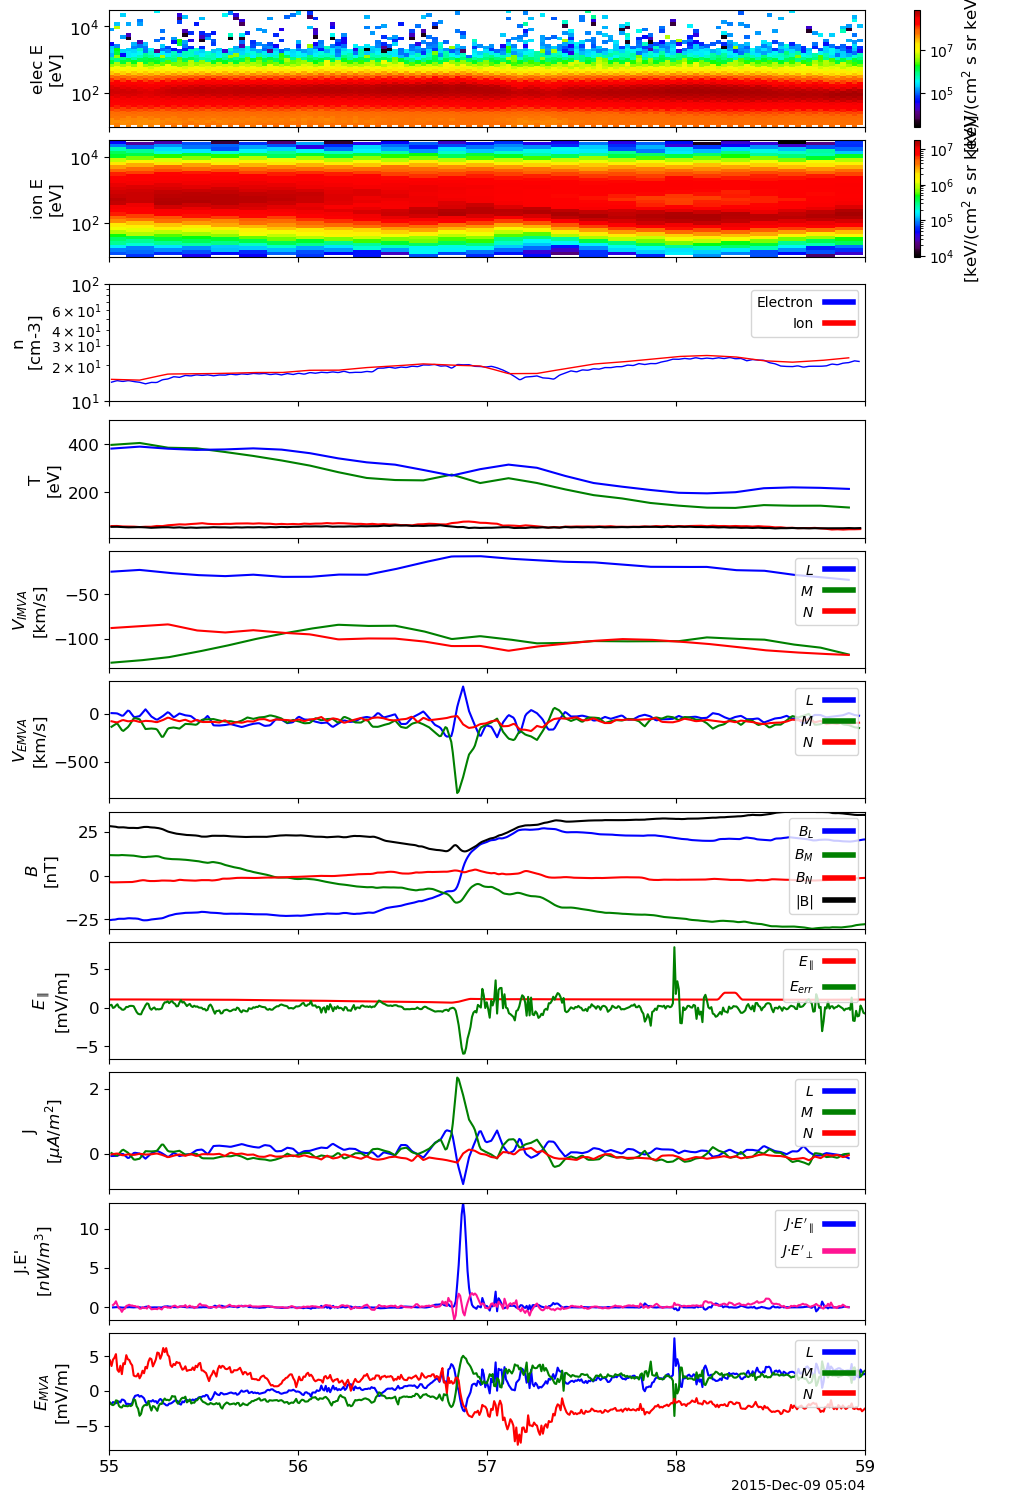

In [122]:
pyspedas.tplot(['ene_omni_e', 'ene_omni_i',
                'combined_density',
                'combined_temp', 
                'bulkv_i_lmn_s',
                'bulkv_e_lmn_s',
                'combined_B_lmn',
                'epar_gse_s',
                'jvec_lmn',
                'combined_j_ep',
                'evec_lmn_s'
                ], xsize=10, ysize=15, save_png='Fig4_Oct6.png')